Primeras filas del dataset:


,image_id,center_id,patient_id,image_num,label
0,006388_0,11,006388,0,CE
1,008e5c_0,11,008e5c,0,CE
2,00c058_0,11,00c058,0,LAA
3,01adc5_0,11,01adc5,0,LAA
4,026c97_0,4,026c97,0,CE



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_id    754 non-null    object
 1   center_id   754 non-null    int64 
 2   patient_id  754 non-null    object
 3   image_num   754 non-null    int64 
 4   label       754 non-null    object
dtypes: int64(2), object(3)
memory usage: 29.6+ KB
None

Resumen estadístico:


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,image_id,center_id,patient_id,image_num,label
count,754,754.000000,754,754.000000,754
unique,754,NaN,632,NaN,2
top,ffec5c_1,NaN,91b9d3,NaN,CE
freq,1,NaN,5,NaN,547
mean,NaN,7.115385,NaN,0.226790,NaN
std,NaN,3.504306,NaN,0.599046,NaN
min,NaN,1.000000,NaN,0.000000,NaN
25%,NaN,4.000000,NaN,0.000000,NaN
50%,NaN,7.000000,NaN,0.000000,NaN
75%,NaN,11.000000,NaN,0.000000,NaN



Valores nulos por columna:
image_id      0
center_id     0
patient_id    0
image_num     0
label         0
dtype: int64

Distribución de clases:
label
CE     547
LAA    207
Name: count, dtype: int64


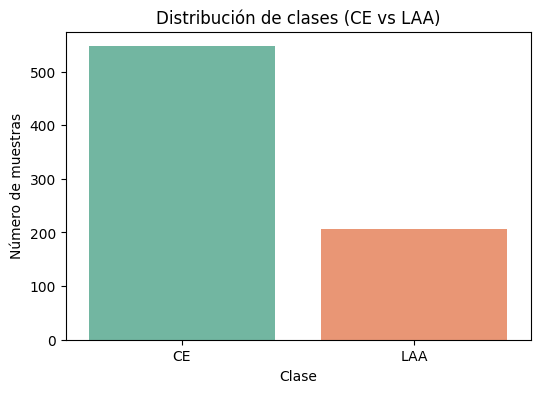

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data_dir = "/kaggle/input/mayo-clinic-strip-ai"
train = pd.read_csv(f"{data_dir}/train.csv")

# 2. Mostrar las primeras filas
print("Primeras filas del dataset:")
display(train.head())

# 3. Información general del dataset
print("\nInformación general:")
print(train.info())

# 4. Resumen estadístico
print("\nResumen estadístico:")
display(train.describe(include="all"))

# 5. Conteo de valores nulos
print("\nValores nulos por columna:")
print(train.isnull().sum())

# 6. Distribución de clases
print("\nDistribución de clases:")
print(train['label'].value_counts())

# 7. Visualización de la distribución de clases
plt.figure(figsize=(6,4))
sns.countplot(data=train, x='label', palette="Set2")
plt.title("Distribución de clases (CE vs LAA)")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.show()

## See Data Structure

In [21]:
import os
contents = os.listdir(f"/kaggle/input/mayo-clinic-strip-ai/train")
print(contents)

['a4c7df_0.tif', 'f9fc6b_0.tif', '0d718a_0.tif', '86e319_1.tif', '54838a_0.tif', 'fe0cca_0.tif', '8781e2_0.tif', '3cbdf3_0.tif', 'ebce5d_0.tif', '41b23c_0.tif', 'a24fac_0.tif', '616c62_1.tif', 'e0b829_0.tif', 'f75146_0.tif', '19dd95_0.tif', 'fd684f_0.tif', '8b90fa_0.tif', '9961af_0.tif', '6fe1f2_0.tif', '4a1152_0.tif', 'af7a93_0.tif', '88623d_0.tif', 'e9c181_0.tif', 'fad610_0.tif', '3d10be_2.tif', '91fee7_0.tif', '53845a_1.tif', '4f49c1_0.tif', 'd7dc3e_0.tif', '821964_0.tif', '83cedb_0.tif', '36a149_0.tif', '3fe88b_0.tif', 'df543d_0.tif', '3d80c7_0.tif', '5f3f01_0.tif', '3ab087_0.tif', '880f54_0.tif', 'a975ab_1.tif', '5ae30a_0.tif', 'b25f2b_0.tif', '652471_0.tif', '280c26_1.tif', 'c4da19_0.tif', '56d177_2.tif', '1d6d4f_0.tif', 'ebb225_0.tif', '45a0e5_0.tif', '369366_0.tif', '42529f_0.tif', 'e3f976_0.tif', '4667f6_0.tif', 'a26055_1.tif', 'f40c69_0.tif', '2394f6_0.tif', 'fa0080_0.tif', '4b8777_0.tif', '140d1a_0.tif', '113bb3_0.tif', '931cea_0.tif', 'edc9a4_0.tif', 'd25a2f_0.tif', '20d5cf

## Data Loader

In [22]:
import openslide
from PIL import Image

def load_downsampled_tiff(path, desired_size=512):
    slide = openslide.OpenSlide(path)

    # Get full resolution
    w, h = slide.dimensions

    # Compute a level that fits desired size
    scale = max(w / desired_size, h / desired_size)
    level = min(
        range(len(slide.level_dimensions)),
        key=lambda l: abs(slide.level_downsamples[l] - scale)
    )

    # Read region at selected level
    region = slide.read_region((0, 0), level, slide.level_dimensions[level]).convert("RGB")

    # Resize exactly to desired size
    region = region.resize((desired_size, desired_size), Image.LANCZOS)
    slide.close()

    return region

In [23]:
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd

Image.MAX_IMAGE_PIXELS = None
class StrokeMILDataset(Dataset):
    def __init__(self, csv_data, image_dir, transform, out_size=512):
        self.data = csv_data
        self.image_dir = image_dir
        self.transform = transform
        self.out_size = out_size
        
        # Encode labels to binary (0 or 1)
        label_mapping = {'CE': 0, 'LAA': 1} 
        self.data['label_encoded'] = self.data['label'].map(label_mapping)
        
        # Group by patient_id to avoid repetition
        self.patient_data = self.data.groupby('patient_id').agg({
            'label_encoded': 'first',  # assumes all images for a patient have same label
            'image_id': list
        }).reset_index()
        
        self.patient_ids = self.patient_data['patient_id'].tolist()
        self.labels = self.patient_data['label_encoded'].tolist()
        self.image_ids = self.patient_data['image_id'].tolist()
        
    def __len__(self):
        return len(self.patient_ids)
    
    def __getitem__(self, idx):
        row = self.patient_data.iloc[idx]
        pid = row.patient_id
        label = row.label_encoded
        imgs = row.image_id

        bag = []
        for img_id in imgs:
            path = os.path.join(self.image_dir, f"{img_id}.tif")
            img = load_downsampled_tiff(path, desired_size=self.out_size)
            if self.transform:
                img = self.transform(img)
            bag.append(img)

        # bag is a list of tensors
        return pid, bag, label

In [24]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    # Valores estandar para imagenes
    transforms.Normalize(
        mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]
    )
])

In [25]:
## Train-Val split

from sklearn.model_selection import train_test_split
import pandas as pd

data_dir = "/kaggle/input/mayo-clinic-strip-ai"
total_data = pd.read_csv(f"{data_dir}/train.csv")
train_df, val_df = train_test_split(
    total_data,
    test_size=0.2,     # 20% validation
    random_state=67,   # for reproducibility
    shuffle=True
)
print(train_df.shape)
val_df = val_df.head(10)
print(val_df.shape)


(603, 5)
(10, 5)


In [26]:
from torch.utils.data import DataLoader

train_ds = StrokeMILDataset(
    train_df,
    f"{data_dir}/train",
    transform=transform
)
val_ds = StrokeMILDataset(
    val_df,
    f"{data_dir}/train",
    transform=transform
)

In [27]:
# train_ds[0]

In [28]:
def mil_collate_fn(batch):
    all_images = []
    bag_sizes = []
    labels = []
    for pid, imgs, label in batch:
        all_images.extend(imgs)
        bag_sizes.append(len(imgs))
        labels.append(label)

    all_images = torch.stack(all_images, dim=0)
    labels = torch.tensor(labels, dtype=torch.long)
    return all_images, bag_sizes, labels


In [29]:
train_dl = DataLoader(
    train_ds, 
    batch_size=4,
    shuffle=True,
    collate_fn=mil_collate_fn
)

val_dl = DataLoader(
    val_ds, 
    batch_size=1, 
    shuffle=True,
    num_workers=0,
    collate_fn=mil_collate_fn
)

In [30]:
# batch = next(iter(train_dl))
# batch

In [31]:
# pid, imgs, label = batch[0]
# imgs

## Model

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# Simple attention pooling from Ilse et al. (2018)
class AttentionPool(nn.Module):
    def __init__(self, in_dim, hidden_dim=128):
        super().__init__()
        self.attn_v = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, mask=None):
        # x: (B, N, D) where N = number of instances in bag
        attn_logits = self.attn_v(x).squeeze(-1)  # (B, N)
        if mask is not None:
            attn_logits = attn_logits.masked_fill(~mask, float('-inf'))
        attn_w = F.softmax(attn_logits, dim=1).unsqueeze(-1)  # (B, N, 1)
        bag = (attn_w * x).sum(dim=1)  # (B, D)
        return bag, attn_w.squeeze(-1)  # return bag embedding and weights

# Example encoder: use a pretrained ResNet and take the final pooled feature
class InstanceEncoder(nn.Module):
    def __init__(self, out_dim=512, pretrained=True):
        super().__init__()
        res = models.resnet18(pretrained=pretrained)
        # remove final fc
        self.backbone = nn.Sequential(*list(res.children())[:-1])  # outputs (B, C, 1, 1)
        self.proj = nn.Linear(res.fc.in_features, out_dim)

    def forward(self, x):
        # x: (B*N, C, H, W) flattened instances
        f = self.backbone(x).view(x.size(0), -1)
        return self.proj(f)  # (B*N, out_dim)

# Whole MIL model
class MILModel(nn.Module):
    def __init__(self, emb_dim=512, attn_hidden=256, n_classes=2, encoder_pretrained=True):
        super().__init__()
        self.encoder = InstanceEncoder(out_dim=emb_dim, pretrained=encoder_pretrained)
        self.attn = AttentionPool(in_dim=emb_dim, hidden_dim=attn_hidden)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )

    def forward(self, bag_images, bag_sizes):
        # bag_images: list of tensors [Ni, C, H, W] OR a single tensor (sum_N, C, H, W)
        # bag_sizes: list or tensor of ints with Ni
        # For efficiency we flatten all instances in batch -> pass through encoder once
        # Example expects bag_images concatenated as (sum_N, C, H, W)
        x = bag_images  # (sum_N, C, H, W)
        feats = self.encoder(x)  # (sum_N, D)
        # rebuild batch-wise (B, N_max, D) with mask
        B = len(bag_sizes)
        Nmax = max(bag_sizes)
        D = feats.size(-1)
        bags = feats.new_zeros((B, Nmax, D))
        mask = torch.zeros((B, Nmax), dtype=torch.bool, device=feats.device)
        idx = 0
        for i, n in enumerate(bag_sizes):
            bags[i, :n] = feats[idx: idx + n]
            mask[i, :n] = True
            idx += n
        bag_emb, attn_w = self.attn(bags, mask=mask)
        logits = self.classifier(bag_emb)
        return logits, attn_w  # attn_w useful for interpretability


## Training

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [34]:
model = MILModel()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay = 1e-5
)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Solo calcular los primeros 32 batches
MAX_BATCHES = 32

import glob
import gc

# Check for existing checkpoints
checkpoints = sorted(glob.glob('/kaggle/working/checkpoint_epoch_*.pt'))

start_epoch = 0
if checkpoints:
    latest_checkpoint = checkpoints[-1]
    print(f"Found checkpoint: {latest_checkpoint}")
    checkpoint = torch.load(latest_checkpoint)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from epoch {start_epoch}")

print("Starting Training!")
for epoch in range(start_epoch, 10):
    # === TRAINING === #
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for batch_idx, (images_concat, bag_sizes, labels) in enumerate(tqdm(train_dl)):
        if batch_idx >= MAX_BATCHES:
            break
        images_concat = images_concat.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits, attn_w = model(images_concat, bag_sizes)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss +=loss.item()*labels.size(0)
        preds = logits.argmax(1)
        correct+=(preds == labels).sum().item()
        total+= labels.size(0)
        print(f"(Epoch {epoch}) {batch_idx}/{MAX_BATCHES}: loss = {loss.item()*labels.size(0):.4f}")

        del images_concat, logits, attn_w, loss
        torch.cuda.empty_cache()
        if (batch_idx % 4 == 0):
            # Every 3 batches, clean cache so notebook doesnt crash
            gc.collect()
            print(f"(Epoch {epoch}) {batch_idx}/{MAX_BATCHES}: loss = {total_loss:.4f}")
    epoch_loss = total_loss /total
    epoch_acc = correct/total
    print(f"(Epoch {epoch}) | Train Loss: {epoch_loss:.4f} | Train Acc {epoch_acc:.4f}")


    # === SAVE === #
    checkpoint_path = f"/kaggle/working/checkpoint_epoch_{epoch}.pt"
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }, checkpoint_path)
    
    # === VALIDATION ==== #
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images_concat, bag_sizes, labels in val_dl:
            images_concat = images_concat.to(device)
            labels = labels.to(device)

            logits, attn_w = model(images_concat, bag_sizes)
            loss = criterion(logits, labels)

            val_loss += loss.item() * labels.size(0)
            preds = logits.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            del images_concat, logits, attn_w, loss

    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_correct / val_total
    print(f"(Epoch {epoch}) | Val  Loss: {val_epoch_loss:.4f} | Val  Acc: {val_epoch_acc:.4f}")
    
    print(f"Checkpoint saved at {checkpoint_path}!")



Found checkpoint: /kaggle/working/checkpoint_epoch_3.pt
Resuming from epoch 4
Starting Training!


  0%|          | 0/129 [00:00<?, ?it/s]

os,